Problem Definition:
This project aims to analyze the long-term performance of three major U.S. tech companies: APPLE, Microsoft, and NVIDIA. The key problem is to compare their risk and return characteristics from 2020 to 2025, including cumulative returns, annualized returns, volatility and maximum drawdown. The goal is to help investors understand the differences in return stability and risk levels among growth-oriented and defensive tech stocks and to support data-driven investment decisions.

In [1]:
# 'import' loads an external libarary
# 'wrds' connects Python to the WRDS financial database server
# 'pandas' is the main library for working with data tables
# 'numpy' supports numerical calculations
# 'matplotlib.pyplot' is for visualizing stock performance later in the analysis
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Establish WRDS Database Connection
db = wrds.Connection(wrds_username='jiayicui24')

Loading library list...
Done


In [3]:
# Define all query parameters as Python variables
tickers = ['AAPL', 'MSFT', 'NVDA']
start_date = "2020-01-01"

In [4]:
# selected_columns is a multi-line string that lists the SQL columns we want.
selected_columns = """
b.htsymbol,
b.permno,
a.date,
a.prc,
a.ret
"""

In [5]:
# Build the SQL query using a Python f-string
# LEFT JOIN combines two tables by matching rows where a.permno = b.permno
sql_query = f"""
SELECT {selected_columns}
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol IN ({','.join([f"'{t}'" for t in tickers])})
AND a.date >= '{start_date}'
"""
print(sql_query)


SELECT 
b.htsymbol,
b.permno,
a.date,
a.prc,
a.ret

FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol IN ('AAPL','MSFT','NVDA')
AND a.date >= '2020-01-01'



In [6]:
# db.raw_sql() sends the SQL query to WRDS and returns a pandas DataFrame
# date_cols=['date'] tells pandas to parse the 'date' column as a proper datetime type instead of keeping it as a plain text string
# This allows filtering and sorting by date later
stock_joined = db.raw_sql(sql_query, date_cols=["date"])
stock_joined

,htsymbol,permno,date,prc,ret
0,MSFT,10107,2020-01-31,170.23,0.079455
1,MSFT,10107,2020-02-28,162.00999,-0.045292
2,MSFT,10107,2020-03-31,157.71001,-0.026542
3,MSFT,10107,2020-04-30,179.21001,0.136326
4,MSFT,10107,2020-05-29,183.25,0.025389
...,...,...,...,...,...
175,NVDA,86580,2024-08-30,119.37,0.020082
176,NVDA,86580,2024-09-30,121.44,0.017425
177,NVDA,86580,2024-10-31,132.75999,0.093215
178,NVDA,86580,2024-11-29,138.25,0.041353


In [7]:
# Rename columns to make the DataFrame esier to read
stock_joined = stock_joined.rename(columns={
    "htsymbol":"ticker",
    "prc":"price",
    "ret":"monthly_return"
})
stock_joined

,ticker,permno,date,price,monthly_return
0,MSFT,10107,2020-01-31,170.23,0.079455
1,MSFT,10107,2020-02-28,162.00999,-0.045292
2,MSFT,10107,2020-03-31,157.71001,-0.026542
3,MSFT,10107,2020-04-30,179.21001,0.136326
4,MSFT,10107,2020-05-29,183.25,0.025389
...,...,...,...,...,...
175,NVDA,86580,2024-08-30,119.37,0.020082
176,NVDA,86580,2024-09-30,121.44,0.017425
177,NVDA,86580,2024-10-31,132.75999,0.093215
178,NVDA,86580,2024-11-29,138.25,0.041353


In [8]:
# Create a copy of the raw joined stock data to avoid modifying the original dataset
df = stock_joined.copy()

In [9]:
# Take the absolute value of the 'price' column
df["price"] = df["price"].abs()

In [10]:
# Sort the dataset by 'ticker' and 'date' to ensure the time series is in order
df = df.sort_values(by=["ticker","date"]).reset_index(drop=True)

In [11]:
# Print the list of column names to confirm the structure of the cleaned dataset
print("columns:", df.columns.tolist())

columns: ['ticker', 'permno', 'date', 'price', 'monthly_return']


In [12]:
# Compute the cumulative return  for each stock
df['cumulative_return'] = df.groupby('ticker')['monthly_return'].transform(
    lambda x: (1 + x.fillna(0)).cumprod() - 1
)

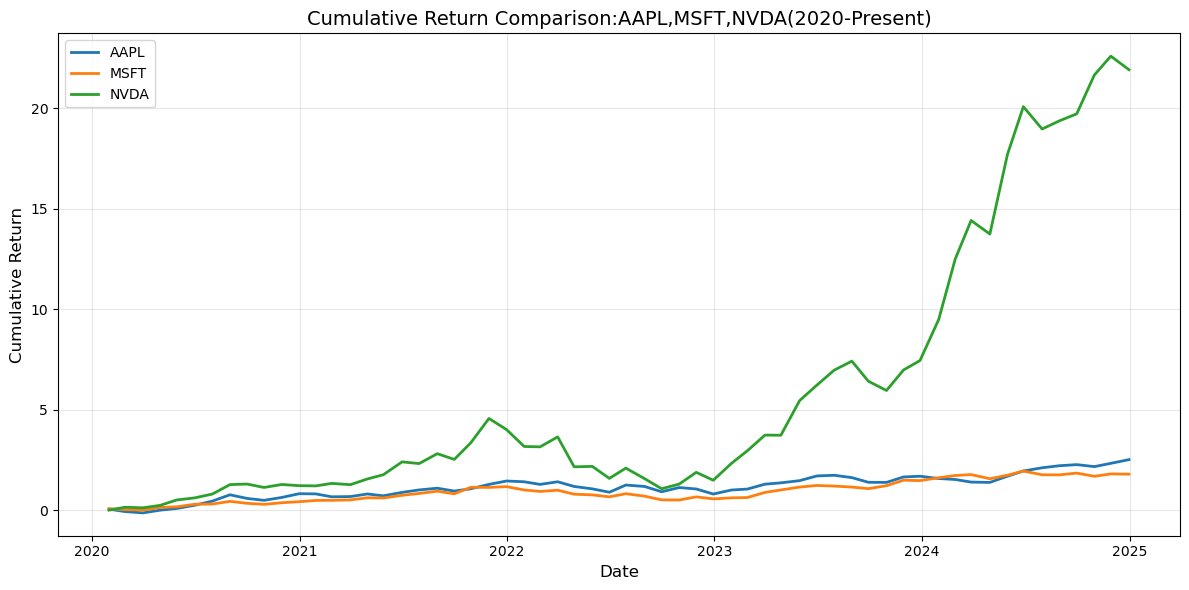

In [13]:
# Generate a line plot to compare the cumulative return of AAPL, MSFT and NVDA from 2020 to the present
# Customize the plot with labels, a title and grid lines for clarity
plt.figure(figsize=(12,6))
for tic in tickers:
    temp = df[df["ticker"] == tic]
    plt.plot(temp["date"], temp["cumulative_return"], label=tic, linewidth=2)
plt.title("Cumulative Return Comparison:AAPL,MSFT,NVDA(2020-Present)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()  

In [14]:
# Computes key performance indicators, annualized return, annualized volatility and max drawdown to evaluate each stock's risk-adjusted return
summary = []
for tic in tickers:
    temp = df[df["ticker"] == tic]
    annual_ret = (1 + temp["monthly_return"].mean()) ** 12 - 1
    annual_vol = temp["monthly_return"].std() * np.sqrt(12)
    max_dd = (temp["cumulative_return"] - temp["cumulative_return"].cummax()).min()

    summary.append({
    "Ticker":tic,
    "Annualized Return": round(annual_ret, 4),
    "Annualized Volatility": round(annual_vol, 4),
    "Max Drawdown": round(max_dd, 4),
    "Total Cumulative Return": round(temp["cumulative_return"].iloc[-1], 4)
    })

summary_df = pd.DataFrame(summary)
print("Risk & Return Summary:")
print(summary_df)

Risk & Return Summary:
  Ticker  Annualized Return  Annualized Volatility  Max Drawdown  \
0   AAPL             0.3376                 0.2893       -0.6481   
1   MSFT             0.2577                 0.2240       -0.6634   
2   NVDA             1.0940                 0.4987       -3.4974   

   Total Cumulative Return  
0                   2.5187  
1                   1.7952  
2                  21.9225  


In [15]:
# Export analysis results to Excel
with pd.ExcelWriter("Tech_Giants_Stock_Analysis.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    summary_df.to_excel(writer, sheet_name="Risk_Return_Metrics", index=False)

In [16]:
# Close the WRDS connection
db.close()